# Ganglion cells cartography

## Setup

### Import libraries:

In [8]:
## Set the right working directory:
import sys
sys.path.append('/home/jovyan/projects/cellcount/')
import os
print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())

import pandas as pd
import numpy as np
#import scipy as sc
import matplotlib.pyplot as plt
# from matplotlib.ticker import MultipleLocator
# from matplotlib import gridspec
%matplotlib inline
from pickle import dump, load
from math import pi

from utils import *

/home/jovyan/projects/cellcount
/home/jovyan/projects/cellcount


### Choose parameters (species):

In [7]:
species = 'Aa14' # 'Hr08' or 'Aa14'

save_intermediary_data = False
save_final_data = False

### Define paths:

In [3]:
path2kdrive = "/home/jovyan/kDrive"
path2mainfolder = os.path.join(path2kdrive, "cellcount/data/project_Aa_Hr_Fovea")
path2folder = os.path.join(path2mainfolder, f"{species}_FT", f"{species}_serial_GC")
path2plots = os.path.join(path2mainfolder, "plots")
path2pickle = os.path.join(path2mainfolder, "pickled_data")
print(f"Plots will be saved in {path2plots}")

Plots will be saved in /home/jovyan/kDrive/cellcount/data/project_Aa_Hr_Fovea/plots


### Define environment variables:

In [4]:
# Image ratio microns/px for all serial images (same for both species)
IMG_RATIO = 1691/2653
print(IMG_RATIO)

0.6373916321145873


## Import and prepare data

### TESTING: Import and process an individual slice

In [5]:
slide_nb = 38
## Hr08:
# img_filename = f"HR08_Ft_serial.lif - Slide{slide_nb}.tif"
# roiset_filename = f"Hr08_Ft_serial GC_slide {slide_nb}_RoiSet.zip"
## Aa14:
img_filename = f"Slide {slide_nb}.lif - slide {slide_nb}.tif"
roiset_filename = f"Slide_{slide_nb}_RoiSet.zip"

<tifffile.TiffPage 0 @53715530> <tifffile.imagej_metadata> raised IndexError('tuple index out of range')


(27054, 17901)


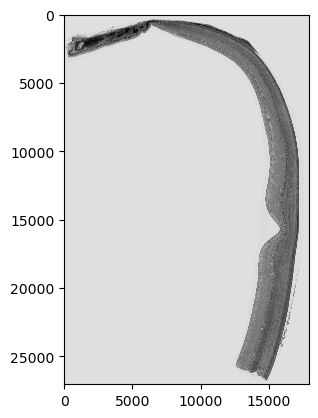

In [6]:
im = io.imread(os.path.join(path2folder, img_filename))
im_dim = im.shape
print(im_dim)
plt.imshow(im, cmap=plt.cm.gray)

In [303]:
# im_flipped = np.flip(im, axis=0)
# plt.imshow(im_flipped, cmap=plt.cm.gray)
# im_rotated = np.rot90(im, k=3, axes=(0, 1)) # rotate pi/2 clockwise
# plt.imshow(im_rotated, cmap=plt.cm.gray)

In [304]:
path2roiset = os.path.join(path2folder, roiset_filename)
rois = read_roi_zip(path2roiset)

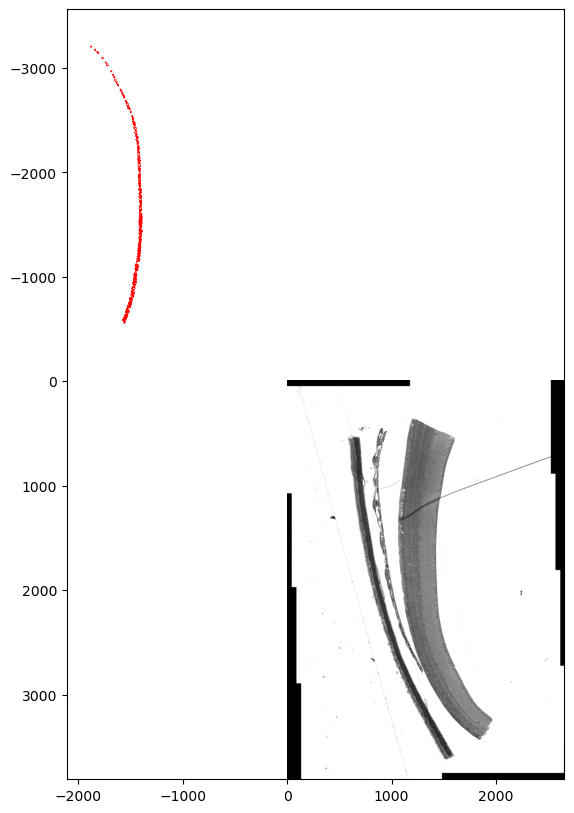

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(30, 10))
#ax.imshow(im_flipped, cmap=plt.cm.gray)
#ax.imshow(im_rotated, cmap=plt.cm.gray)
ax.imshow(im, cmap=plt.cm.gray)

polygon_list = []
for r in rois:
    #print(r)
    if rois[r]['type'] == 'line':
        pass
    else:
        #coords = flip_roiset(np.array(rois[r]['x']), np.array(rois[r]['y']), im.shape)
        #coords = rotate_roiset(np.array(rois[r]['x']), np.array(rois[r]['y']), pi, im_rotated.shape)
        coords = rotate_roiset(np.array(rois[r]['x']), np.array(rois[r]['y']), pi, (0,0))
        polygon_list.append((r, contour2polygon(coords)))
        ax.plot(coords[:,0], coords[:,1], linewidth=0.5, color='red')

### Define the slides labels

In [15]:
if species == 'Hr08':
    slide_range = list(range(9, 47))
    slide_range.remove(24) # slide 24 is missing
elif species == 'Aa14':
    slide_range = list(range(24, 61))
    slide_range.remove(38) # slide 38 is with another (much higher) resolution
print(slide_range)

[24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]


### Plot a mosaic of all serial slides (optional)

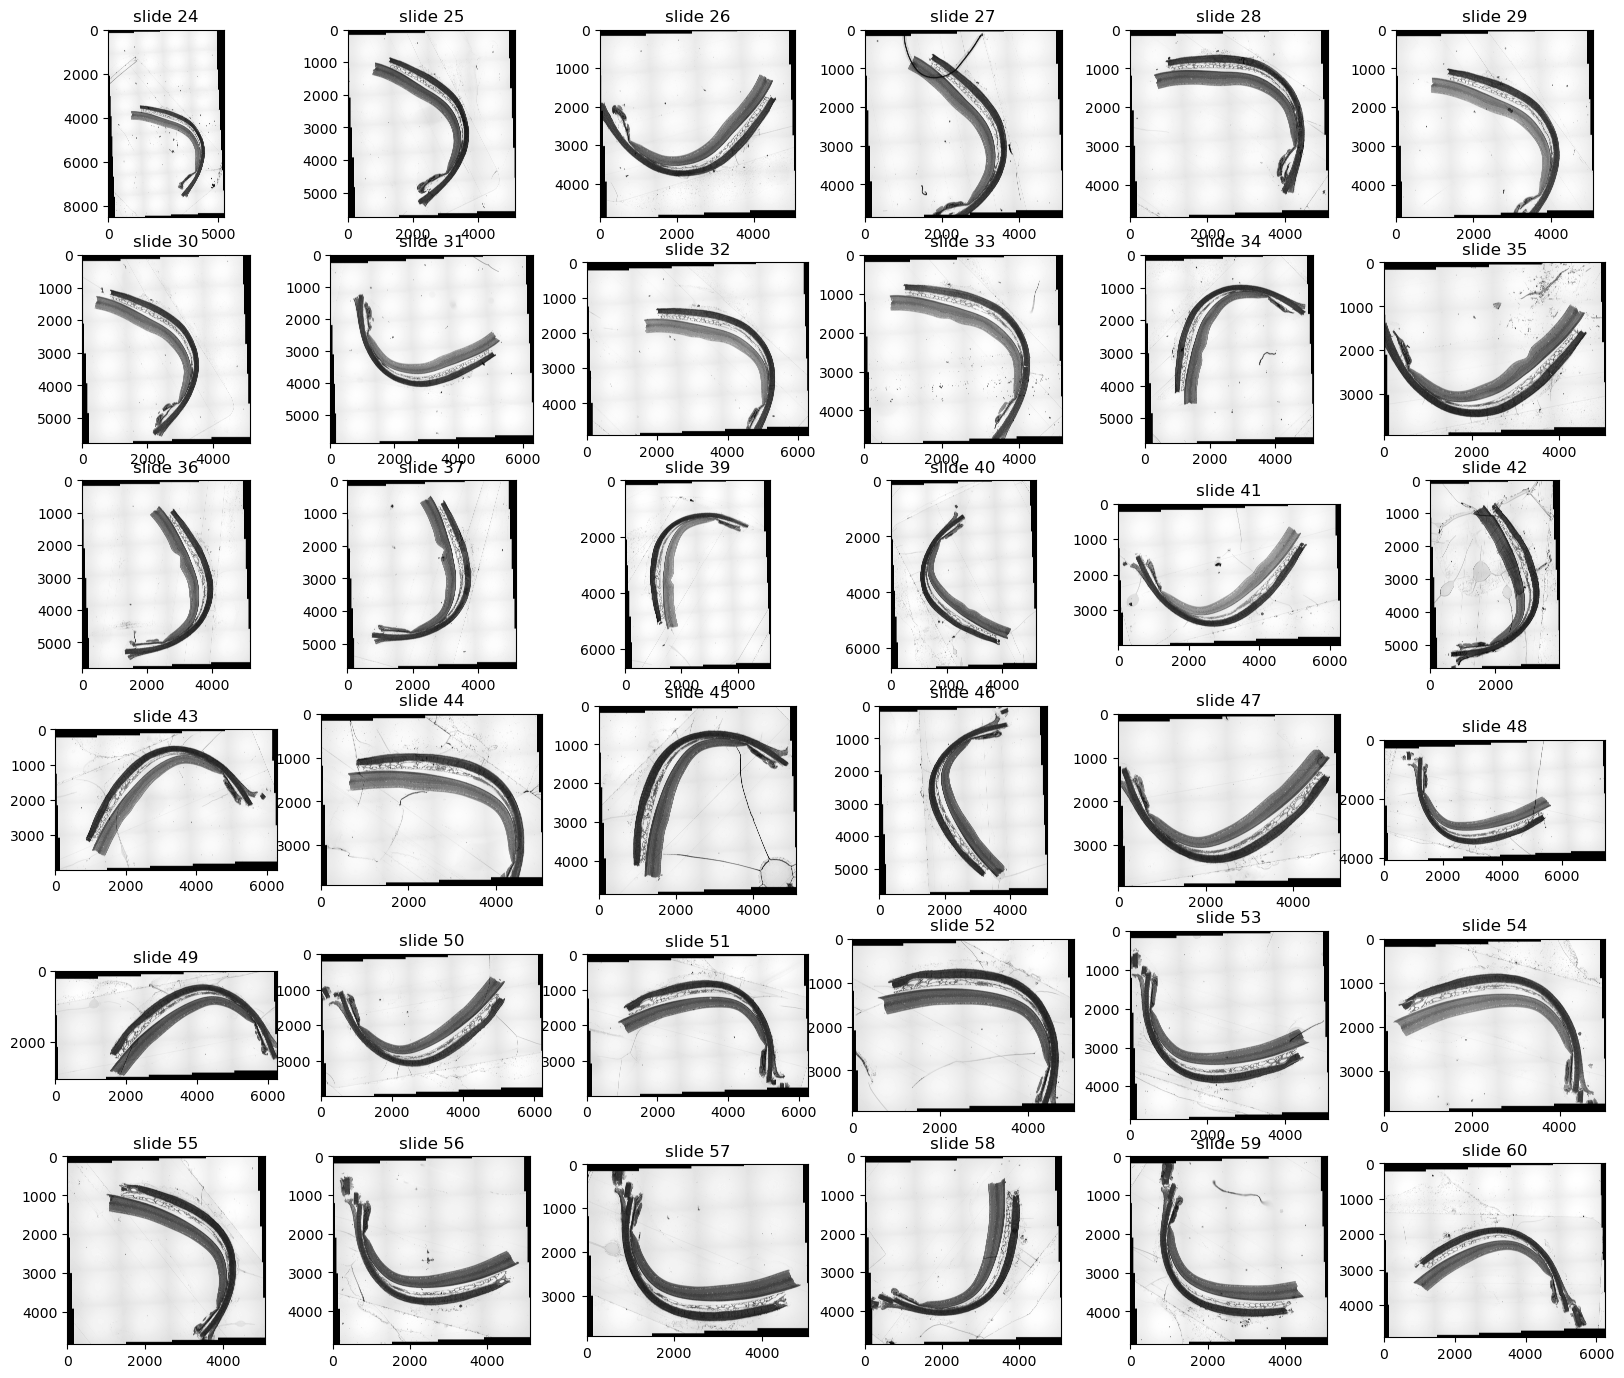

In [ ]:
nrows = 7
ncols = 6
fig = plt.figure(figsize=(20, 20))
spec = fig.add_gridspec(nrows, ncols)
idx = 0
for i in range(nrows):
    for j in range(ncols):
        ax = fig.add_subplot(spec[i,j])
        if species == 'Hr08':
            img_filename = f"HR08_Ft_serial.lif - Slide{slide_range[idx]}.tif"
        elif species == 'Aa14':
            img_filename = f"Slide {slide_range[idx]}.lif - slide {slide_range[idx]}.tif"
        im = io.imread(os.path.join(path2folder, img_filename))
        ax.imshow(im, cmap=plt.cm.gray)
        ax.set_title(f"slide {slide_range[idx]}")
        idx += 1
        if idx >= len(slide_range):
            break

    if idx >= len(slide_range):
            break

if save_intermediary_data:
    print("save plot")
    fig.savefig(os.path.join(path2plots, f"{species}_FT_serial_mosaic.png"), facecolor='white')

### Rotate and plot all roisets (optional if roisets already saved)

In [ ]:
## Define rotation for each slide
if species == 'Hr08':
    slide_rotation_angles = {
        9: 0,
        10: -pi/2,
        11: 3*pi/4,
        12: 9*pi/8,
        13: 5*pi/8,
        14: -3*pi/4,
        15: 5*pi/16,
        16: -pi/2,
        17: -pi/2,
        18: -pi/2,
        19: 9*pi/8,
        20: -5*pi/8,
        21: 3*pi/4,
        22: 3*pi/8,
        23: 0,
        25: pi/8,
        26: -pi/8,
        27: -3*pi/8,
        28: 15*pi/16,
        29: 5*pi/8,
        30: pi,
        31: 0,
        32: -3*pi/8,
        33: -pi/4,
        34: -11*pi/16,
        35: 3*pi/16,
        36: -11*pi/16,
        37: pi/2,
        38: -5*pi/8,
        39: 3*pi/8,
        40: 3*pi/4,
        41: pi,
        42: 7*pi/16,
        43: pi/4,
        44: pi/4,
        45: 5*pi/8,
        46: -pi/2
    }
elif species == 'Aa14':
        slide_rotation_angles = {
        24: pi/3,
        25: pi/4,
        26: -pi/4,
        27: pi/6,
        28: 5*pi/12,
        29: pi/3,
        30: pi/3,
        31: -5*pi/12,
        32: pi/3,
        33: pi/3,
        34: 9*pi/10,
        35: -pi/3,
        36: 5*pi/48,
        37: 0,
        #38: pi,
        39: 9*pi/10,
        40: 12*pi/10,
        41: -pi/3,
        42: pi/12,
        43: 7*pi/10,
        44: 5*pi/12,
        45: 8*pi/10,
        46: 11*pi/10,
        47: -pi/3,
        48: -5*pi/12,
        49: 6*pi/10,
        50: -pi/3,
        51: pi/2,
        52: 5*pi/12,
        53: -pi/2,
        54: pi/2,
        55: pi/3,
        56: -pi/2,
        57: -pi/2,
        58: -pi/12,
        59: -7*pi/12,
        60: 7*pi/12
    }

shift back: 4072.25
shift back: 1378.5
shift back: 1205.25
shift back: 1002.25
shift back: 1362.0
shift back: 1604.25
shift back: 1612.6666259765625
shift back: 2408.5
shift back: 1956.6666259765625
shift back: 1387.5
shift back: 1265.5
shift back: 986.5
shift back: 1087.5
shift back: 691.0
shift back: 1570.0
shift back: 2581.0
shift back: 654.75
shift back: 1001.6666870117188
shift back: 910.25
shift back: 1650.3333740234375
shift back: 991.3333129882812
shift back: 1532.3333740234375
shift back: 849.0
shift back: 1953.75
shift back: 911.3333129882812
shift back: 680.3333129882812
shift back: 1422.0
shift back: 1444.25
shift back: 2596.0
shift back: 1467.3333740234375
shift back: 1374.0
shift back: 2470.666748046875
shift back: 2011.3333740234375
shift back: 719.3333129882812
shift back: 2590.5
shift back: 2370.25


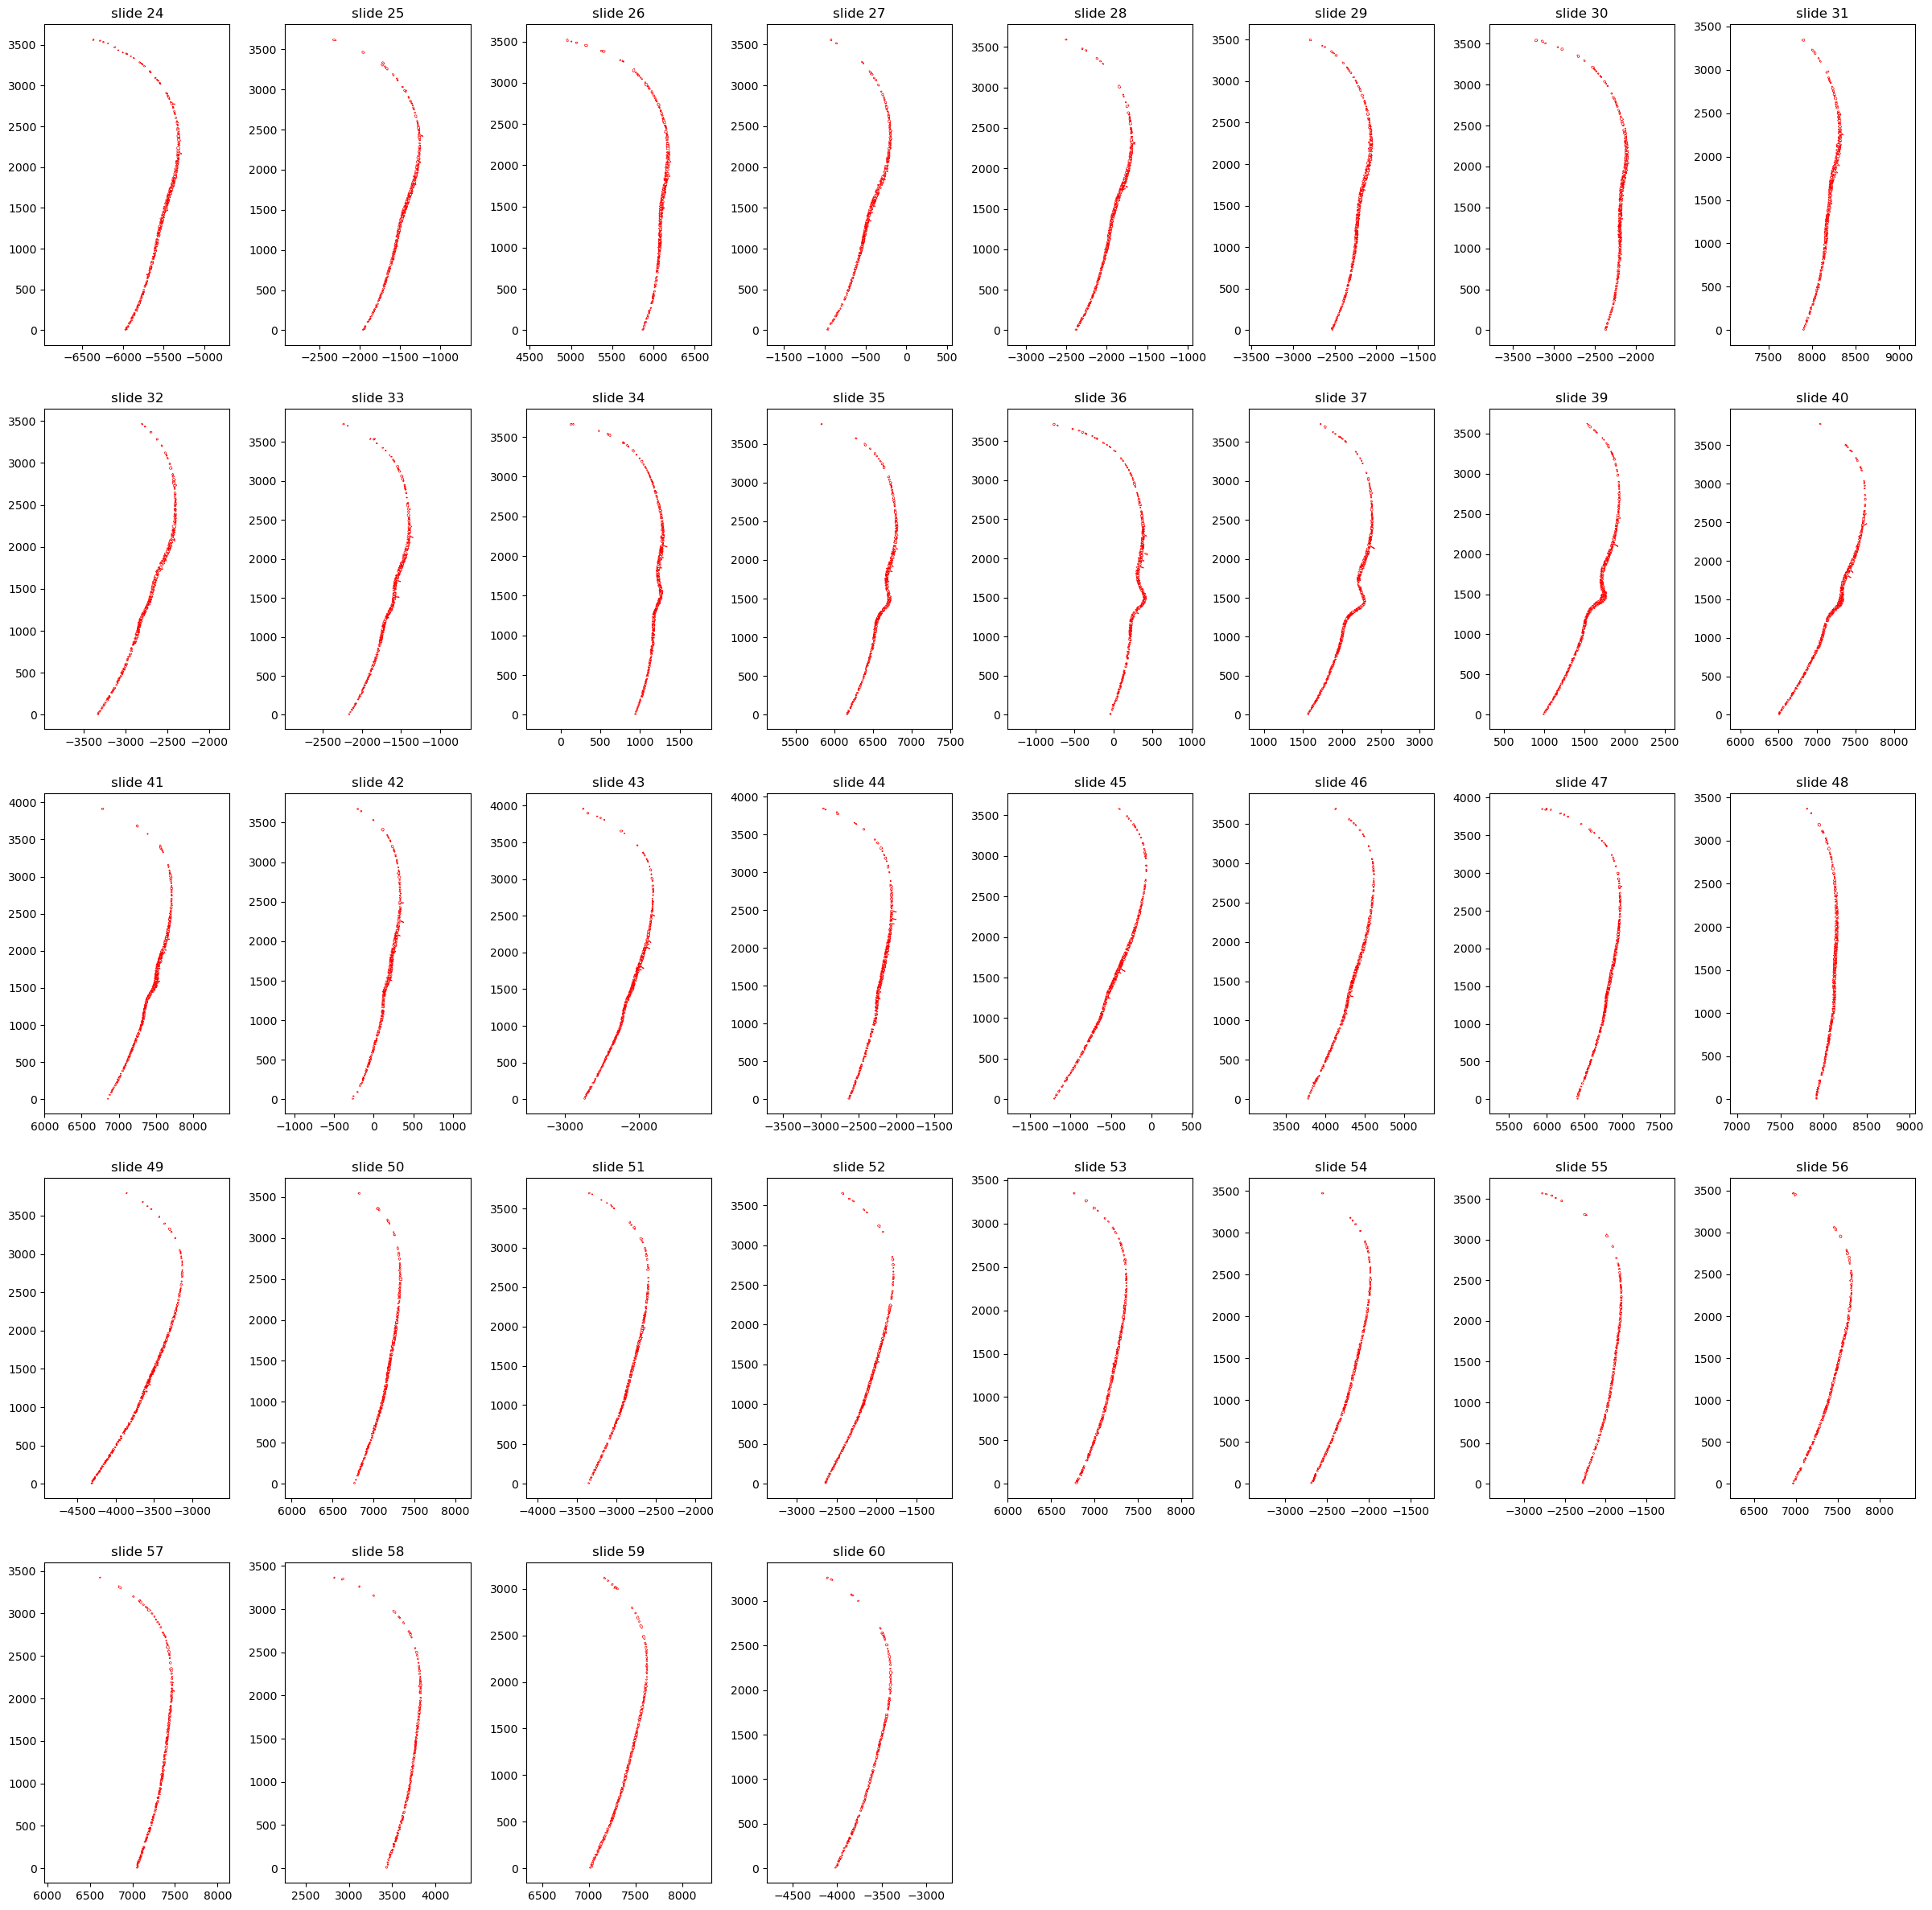

In [20]:
nrows = 5
ncols = 8
fig = plt.figure(figsize=(30, 30))
spec = fig.add_gridspec(nrows, ncols, wspace=0.3)
all_slides_polygons = {}
idx = 0
for i in range(nrows):
    for j in range(ncols):
        ax = fig.add_subplot(spec[i,j])
        if species == 'Hr08':
            roiset_filename = f"Hr08_Ft_serial GC_slide {slide_range[idx]}_RoiSet.zip"
        elif species == 'Aa14':
            roiset_filename = f"Slide_{slide_range[idx]}_RoiSet.zip"
        path2roiset = os.path.join(path2folder, roiset_filename)
        rois = read_roi_zip(path2roiset)
        ## get the minimum y-coordinate in order to shift all rois to zero along the center (y=0) -> periphery direction:
        roi_y_min = [min(rois[r]['y']) for r in rois]
        slide_y_min = min(roi_y_min)
        print(f"shift back: {slide_y_min}")
        polygon_list = []
        slide_y_min = None
        for r in rois:
            if rois[r]['type'] == 'line':
                pass
            else:
                coords = rotate_roiset(np.array(rois[r]['x']), np.array(rois[r]['y']), slide_rotation_angles[slide_range[idx]], (0,0))
                roi_min = min(coords[:,1])
                if slide_y_min is not None:
                    if roi_min < slide_y_min:
                        slide_y_min = roi_min
                else:
                    slide_y_min = roi_min 
                ## shift back all rois to zero along the center (y=0) -> periphery direction:
                coords = coords - slide_y_min
                polygon_list.append((r, contour2polygon(coords)))
                ax.plot(coords[:,0], coords[:,1], linewidth=0.5, color='red')
                all_slides_polygons[slide_range[idx]] = polygon_list

        ax.axis('equal')
        ax.set_title(f"slide {slide_range[idx]}")
        idx += 1
        if idx >= len(slide_range):
            break


if save_intermediary_data:
    print("save plot")
    fig.savefig(os.path.join(path2plots, f"{species}_FT_serial_mosaic_GC_rois.png"), facecolor='white')

    # Save data for further use:
    print("save data")
    pickle_filename = f"GC_{species}_FT_serial.pickle"
    with open(os.path.join(path2pickle, pickle_filename), 'bw') as f:
        dump(all_slides_polygons, f)

In [ ]:
# LARGE_GC_THR = 100

# large_gc_nb = {}
# for k in roisets_all: # loop on slices
#     rois = roisets_all[k]
#     polygon_list = []
#     for r in rois: # loop on each roiset (i.e. each cell) in a given slice
#         if rois[r]['type'] == 'line':
#             pass
#         else:
#             coords = np.column_stack((np.array(rois[r]['x']), np.array(rois[r]['y'])))
#             polygon_list.append((r, contour2polygon(coords)))

#     areas = [polygon_list[i][1].area * IMG_RATIO**2 for i in range(len(polygon_list))]
#     large_gc_nb[k] = len([a for a in areas if a > LARGE_GC_THR])

### Prepare data for discrete heatmap and marginal histograms

In [21]:
# Load previously rotated rois:
pickle_filename = f"GC_{species}_FT_serial.pickle"
print(f"loading {pickle_filename}")
with open(os.path.join(path2pickle, pickle_filename), 'rb') as f:
    all_slides_polygons = load(f)
    
all_slides_polygons.keys()

loading GC_Aa14_FT_serial.pickle


dict_keys([24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60])

#### Number of ganglion cells in each slice of FT:

Get the counts of GC in each slide as well as the centroids of (large) GC in order to display a heatmap

In [25]:
## count number of GC larger than LARGE_GC_THR
LARGE_GC_THR = 200

large_gc_nb = {}
gc_nb = {}
all_slides_centroids_large_y = {}
all_slides_centroids_all_y = {}
for s in all_slides_polygons:
    # unzip the tuples (roi_id, roi_polygon) contained in each element of all_slides_polygons:
    roi_id, roi_polygons = zip(*all_slides_polygons[s])
    # get the centroids:
    centroids_large = [poly.centroid for poly in roi_polygons if poly.area * IMG_RATIO**2 > LARGE_GC_THR]
    centroids_all = [poly.centroid for poly in roi_polygons]
    # get the y-coordinates (in px) which represents the distance from retina center and convert it to microns:
    #centroids_x = [i.coords[0][0] for i in centroids] # not needed
    centroids_large_y = [i.coords[0][1] * IMG_RATIO for i in centroids_large]
    all_slides_centroids_large_y[s] = centroids_large_y
    centroids_all_y = [i.coords[0][1] * IMG_RATIO for i in centroids_all]
    all_slides_centroids_all_y[s] = centroids_all_y
    gc_nb[s] = len(centroids_all)
    large_gc_nb[s] = len(centroids_large)


## Concatenate in a single list all centroids (for the upper plot):
centroids_pooled_y = sum(list(all_slides_centroids_all_y.values()), [])

## Organize the counts in each slice in a Dataframe:
df_gc_counts = pd.DataFrame({'slice': list(all_slides_polygons.keys()), 'all_counts': list(gc_nb.values()), 'large_counts': list(large_gc_nb.values())})
df_gc_counts

,slice,all_counts,large_counts
0,24,267,14
1,25,247,27
2,26,232,35
3,27,249,21
4,28,275,21
5,29,277,28
6,30,241,27
7,31,252,28
8,32,233,26
9,33,266,25


In [26]:
print(f"Total number of GC larger than {LARGE_GC_THR} microns^2: {df_gc_counts.large_counts.sum()}")
print(f"Total number of GC: {df_gc_counts.all_counts.sum()}")
print(f"Ration of large GC: {df_gc_counts.large_counts.sum()/df_gc_counts.all_counts.sum()}")

Total number of GC larger than 200 microns^2: 673
Total number of GC: 8465
Ration of large GC: 0.07950383933845245


## Plot data

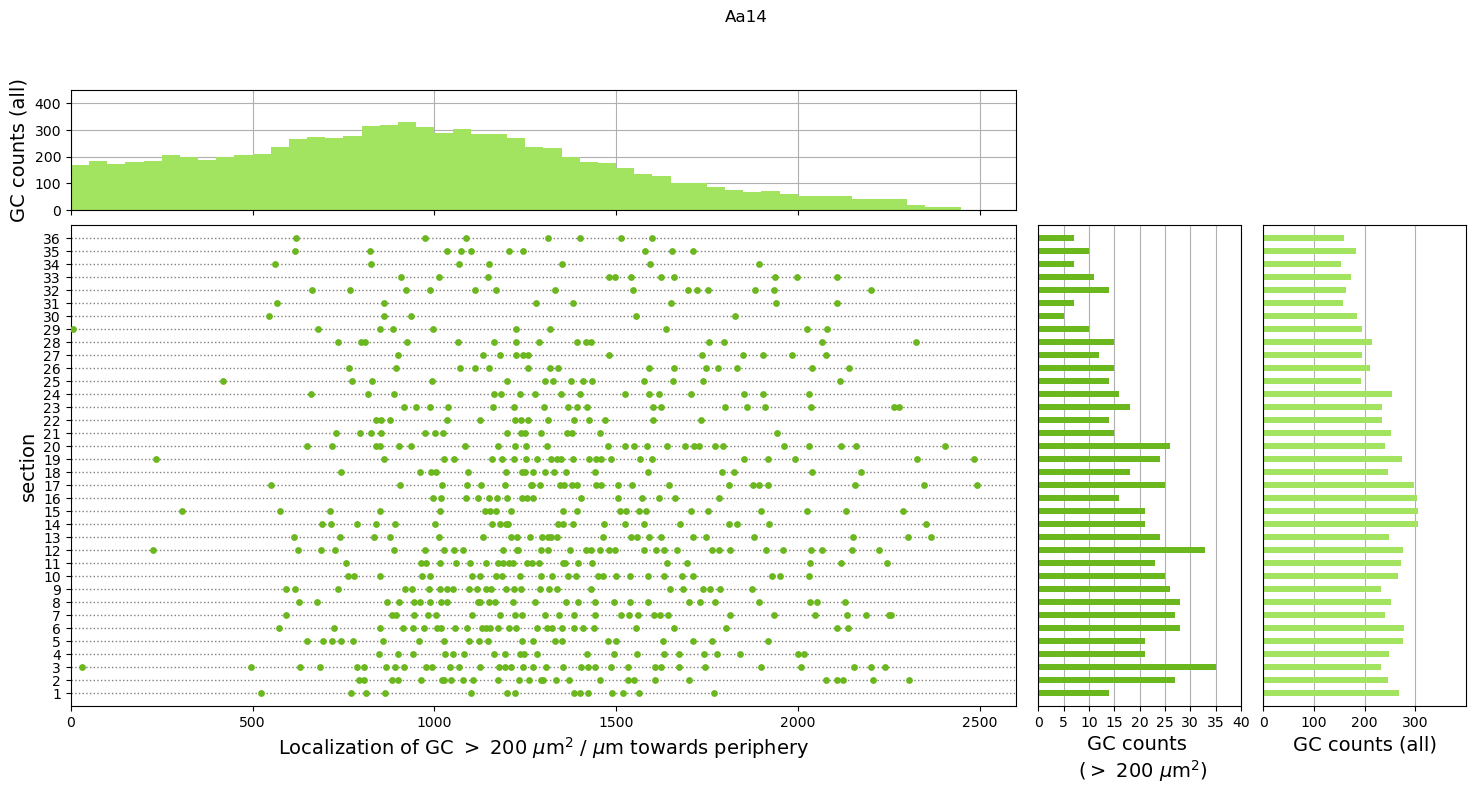

In [33]:
COLOR = '#6BB71E'
COLOR_LIGHT = '#A2E460'
if species == 'Hr08':
    x_limits = (0, 1950)
elif species == 'Aa14':
    x_limits = (0, 2600)

fig = plt.figure(figsize=(18, 8))
spec = fig.add_gridspec(nrows=2, ncols = 3, width_ratios=[0.7, 0.15, 0.15], height_ratios=[0.2, 0.8], wspace=0.05, hspace=0.05)
fig.suptitle(species)

### Upper-left plot (marginal distribution for direction center -> periphery):
ax = fig.add_subplot(spec[0,0])
ax.set_xlim(x_limits[0], x_limits[1])
ax.set_ylim(0, 450)
y_ticks = np.arange(0, 500, 100)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks)
ax.set_xticklabels("")
ax.set_ylabel("GC counts (all)", fontsize=14)
#ax.set_title("upper-left plot", fontsize=12)
bins_width = 50 # set here bins width in microns
bins_edges = np.arange(0, 2500, bins_width) # old 2000
h, bins, _ = ax.hist(centroids_pooled_y,
                    bins_edges,
                    density=False,
                    color=COLOR_LIGHT,
                    zorder=2
)
ax.grid()

### Left most plot - heatmap:
y_ticks = list(df_gc_counts.index+1)
ax0 = fig.add_subplot(spec[1,0])
ax0.set_xlim(x_limits[0], x_limits[1])
ax0.set_xlabel(f"Localization of GC $>$ {LARGE_GC_THR} $\mu$m$^2$ / $\mu$m towards periphery", fontsize=14)
ax0.set_ylabel(f"section", fontsize=14)
ax0.set_yticks(y_ticks)
ax0.set_yticklabels(y_ticks)
if species == 'Hr08':
    ax0.set_ylim(0, 38)
elif species == 'Aa14':
    ax0.set_ylim(0, 37)

idx = 0
for s in all_slides_centroids_large_y:
    idx += 1
    ax0.scatter(all_slides_centroids_large_y[s], idx*np.ones((1, len(all_slides_centroids_large_y[s]))), color=COLOR, s=15, zorder=3)
    ax0.hlines(idx, x_limits[0], x_limits[1], linestyle='dotted', color="#808080", linewidth=1, zorder=2)

#ax0.text(50, 23.75, 'missing section', fontsize=8)

### barplots of marginal counts:
x_ticks = np.arange(0, 45, 5)
width = 0.5  # the width of the bars
ax1 = fig.add_subplot(spec[1,1])
ax1.barh(list(df_gc_counts.index+1), df_gc_counts['large_counts'], height=width, label='large_counts', zorder=2, color=COLOR)
ax1.set_xticks(x_ticks)
ax1.set_xlim(0, 40)
ax1.set_xticklabels(x_ticks)
ax1.set_yticks([])
ax1.set_yticklabels("")
if species == 'Hr08':
    ax1.set_ylim(0, 38)
elif species == 'Aa14':
    ax1.set_ylim(0, 37)
# ax1.set_yticks(y_ticks)
# ax1.set_yticklabels((y_ticks * 20) - 180)
# ax1.set_ylabel('position / $\mu m$')

ax1.set_xlabel(f"GC counts \n ($>$ {LARGE_GC_THR} $\mu$m$^2$)", fontsize=14)
ax1.grid()

ax2 = fig.add_subplot(spec[1,2])
ax2.barh(list(df_gc_counts.index+1), df_gc_counts['all_counts'], height=width, label='all counts', zorder=2, color=COLOR_LIGHT)
x_ticks = np.arange(0, 400, 100)
ax2.set_xlim(0, 400)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(x_ticks)
ax2.set_yticks([])
ax2.set_yticklabels("")
if species == 'Hr08':
    ax2.set_ylim(0, 38)
elif species == 'Aa14':
    ax2.set_ylim(0, 37)
ax2.set_xlabel("GC counts (all)", fontsize=14)

#plt.title()
ax2.grid()

if save_final_data:
    fig.savefig(os.path.join(path2plots, f"GC_in_{species}_FT_serial_{LARGE_GC_THR}"), facecolor='white')
